git add makemore-master/
git commit -m "更新说明"
git push origin main

In [6]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
#read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [8]:
len(words)

32033

In [9]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
#bulid the dataset
def build_dataset(words):
    block_size = 3
    X,Y = [],[]
    for w in words:
    #print(w)
        context = [0]*block_size
        for ch in w +'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'--->',itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])  #X_train,Y_train
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


![](images/2026-10-03-22-22-49.png)
![](images/2026-10-03-22-23-18.png)
![](images/2026-10-03-22-24-04.png)

![](images/2026-10-03-22-27-37.png)
![](images/2026-10-03-22-27-50.png)
![](images/2026-10-03-22-29-26.png)

In [13]:
Xtr.shape,Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator = g)
W1 = torch.randn((6,100),generator = g)
b1 = torch.randn(100,generator = g)
W2 = torch.randn((100,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True 

In [27]:
sum(p.nelement() for p in parameters)

3481

In [29]:
lre = torch.linspace(-3,0,1000) #learning rate exponent 学习率指数
lrs = 10**lre               #learning rate

In [30]:
lri = []
lossi = []

#小批量梯度下降
for i in range(10000):
    #mini-batch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))

    #forward pass
    emb = C[Xtr[ix]]  #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)  #(32,100)
    logits = h @ W2 + b2    #(32,27)
    loss = F.cross_entropy(logits,Ytr[ix])    
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad

    #lri.append(lre[i])
    #lossi.append(loss.item())
print(loss.item())


2.849510431289673


In [31]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.5700, grad_fn=<NllLossBackward0>)

In [32]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.5647, grad_fn=<NllLossBackward0>)

#上面的大循环是在训练集上训练神经网络，而下面两个单元格是在分别计算模型在“训练集”和“验证集”上的整体损失
![](images/2026-10-03-23-27-05.png)
![](images/2026-10-03-23-27-57.png)

In [ ]:
#增加隐藏层神经元数量
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator = g)
W1 = torch.randn((6,300),generator = g)
b1 = torch.randn(300,generator = g)
W2 = torch.randn((300,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True 

In [37]:
sum(p.nelement() for p in parameters)

10281

In [46]:
lri = []
lossi = []
stepi = []

#小批量梯度下降
for i in range(30000):
    #mini-batch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))

    #forward pass
    emb = C[Xtr[ix]]  #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)  #(32,100)
    logits = h @ W2 + b2    #(32,27)
    loss = F.cross_entropy(logits,Ytr[ix])    
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad

    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())
print(loss.item())


2.173551082611084


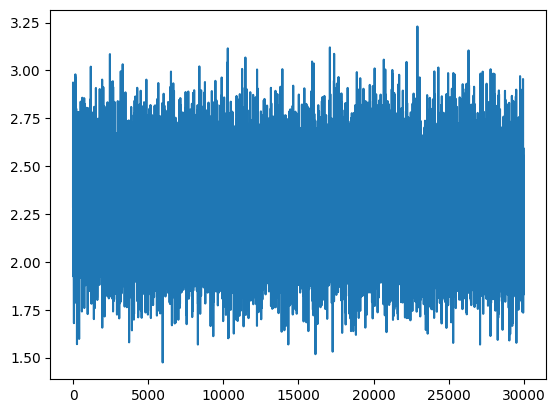

In [47]:
plt.plot(stepi,lossi)

![](images/2026-10-04-00-03-13.png)
![](images/2026-10-04-00-03-31.png)
![](images/2026-10-04-00-04-32.png)

In [48]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.2689, grad_fn=<NllLossBackward0>)

In [49]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.2716, grad_fn=<NllLossBackward0>)

In [ ]:
#增加字符向量的维度
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator = g)
# 每一个字符从原来的 2 维向量变成了 10 维向量。
W1 = torch.randn((30,200),generator = g)
# 因为输入是 3 个字符，每个 10 维，拼接后长度是 30 (3 * 10 = 30)。
# 隐藏层有 200 个神经元，所以矩阵形状是 (30, 200)。
b1 = torch.randn(200,generator = g)
# 对应 200 个神经元的偏置项。
W2 = torch.randn((200,27),generator = g)
# 从 200 个隐藏层神经元映射到 27 个输出字符的概率得分。
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True 

In [64]:
sum(p.nelement() for p in parameters)

11897

In [65]:
lri = []
lossi = []
stepi = []

In [78]:
#小批量梯度下降
for i in range(50000):
    #mini-batch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))

    #forward pass
    emb = C[Xtr[ix]]  
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)  
    logits = h @ W2 + b2    
    loss = F.cross_entropy(logits,Ytr[ix])    
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()
    #update
    #lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr*p.grad

    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())


2.1445016860961914


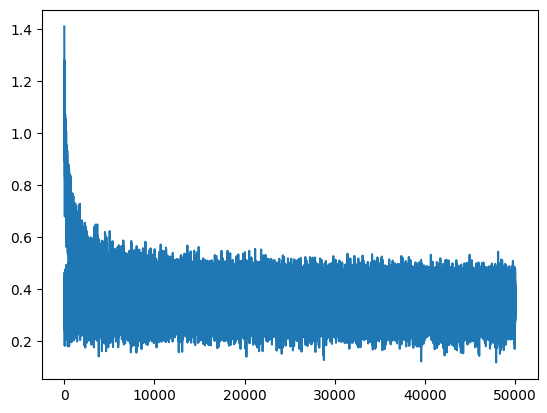

In [79]:
plt.plot(stepi,lossi)

In [80]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.2075, grad_fn=<NllLossBackward0>)

In [81]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.2662, grad_fn=<NllLossBackward0>)

In [ ]:
#模型推理生成(采样生成新名字)
g = torch.Generator().manual_seed(2147483647)
block_size = 3
for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]    #(1,block_size,d)
        h = torch.tanh(emb.view(1,-1)@W1 +b1)
        logits = h@W2 + b2
        probs = F.softmax(logits,dim = 1)
        ix = torch.multinomial(probs,num_samples = 1,generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))


junide.
capphir.
prenay.
ember.
juliltoni.
amarie.
lulania.
zamilenias.
deyaile.
amellseja.
evy.
artelfarium.
ryfferum.
rognis.
waleyan.
reora.
yar.
ocely.
jamille.
zolin.


![](images/2026-10-04-10-15-47.png)
![](images/2026-10-04-10-15-58.png)
![](images/2026-10-04-10-20-26.png)
![](images/2026-10-04-10-20-40.png)
